### **ULTIMATE QUESTION** - *Can physiological information in EEG signals be extracted through signal processing and used for automated neural-state classification?*

# Importing Dataset

In [1]:
import os
for root, dirs, files in os.walk("/content/drive/MyDrive/eeg-during-mental-arithmetic-tasks-1.0.0"):
  level = root.replace("/content/drive/MyDrive/eeg-during-mental-arithmetic-tasks-1.0.0", "").count(os.sep)
  indent = " " * level
  print(f"{indent}{os.path.basename(root)}/")

  for file in files[:10]:
    print(f"{indent} {file}")

eeg-during-mental-arithmetic-tasks-1.0.0/
 Subject29_2.edf
 Subject24_1.edf
 Subject12_2.edf
 Subject02_2.edf
 Subject15_1.edf
 Subject16_1.edf
 SHA256SUMS.txt
 Subject08_1.edf
 Subject34_2.edf
 Subject32_1.edf


# Import MNE

In [2]:
!pip install mne

In [3]:
import mne
import numpy as np
import matplotlib.pyplot as plt
print("MNE version:", mne.__version__)

MNE version: 1.12.1


# EDF Files

In [4]:
import glob
edf_files = glob.glob("/content/drive/MyDrive/eeg-during-mental-arithmetic-tasks-1.0.0/**/*.edf", recursive=True)
print("Number of EDF files:", len(edf_files))

for f in edf_files[:10]:
  print(f)

Number of EDF files: 72
/content/drive/MyDrive/eeg-during-mental-arithmetic-tasks-1.0.0/Subject29_2.edf
/content/drive/MyDrive/eeg-during-mental-arithmetic-tasks-1.0.0/Subject24_1.edf
/content/drive/MyDrive/eeg-during-mental-arithmetic-tasks-1.0.0/Subject12_2.edf
/content/drive/MyDrive/eeg-during-mental-arithmetic-tasks-1.0.0/Subject02_2.edf
/content/drive/MyDrive/eeg-during-mental-arithmetic-tasks-1.0.0/Subject15_1.edf
/content/drive/MyDrive/eeg-during-mental-arithmetic-tasks-1.0.0/Subject16_1.edf
/content/drive/MyDrive/eeg-during-mental-arithmetic-tasks-1.0.0/Subject08_1.edf
/content/drive/MyDrive/eeg-during-mental-arithmetic-tasks-1.0.0/Subject34_2.edf
/content/drive/MyDrive/eeg-during-mental-arithmetic-tasks-1.0.0/Subject32_1.edf
/content/drive/MyDrive/eeg-during-mental-arithmetic-tasks-1.0.0/Subject18_1.edf


In [5]:
# Selecting one recording

edf_path = edf_files[0]
print(edf_path)

/content/drive/MyDrive/eeg-during-mental-arithmetic-tasks-1.0.0/Subject29_2.edf


In [6]:
# Reading the EEG

raw = mne.io.read_raw_edf(
    edf_path,
    preload=True,
    verbose=False
)

In [7]:
print(raw)

<RawEDF | Subject29_2.edf, 21 x 31000 (62.0 s), ~5.0 MiB, data loaded>


In [8]:
print(raw.info)

<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fp1, EEG Fp2, EEG F3, EEG F4, EEG F7, EEG F8, EEG T3, EEG ...
 chs: 21 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 45.0 Hz
 meas_date: 2011-01-01 00:00:00 UTC
 nchan: 21
 projs: []
 sfreq: 500.0 Hz
 subject_info: <subject_info | his_id: 22, sex: 2, last_name: Subject29, birthday: 1992-01-01>
>


In [9]:
# Extract the important information

print("Sampling frequency:", raw.info["sfreq"], "Hz")
print("Number of channels:", len(raw.ch_names))
print("Duration:", raw.times[-1], "seconds")


print("\nChannel names:")
print(raw.ch_names)

Sampling frequency: 500.0 Hz
Number of channels: 21
Duration: 61.998 seconds

Channel names:
['EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG T3', 'EEG T4', 'EEG C3', 'EEG C4', 'EEG T5', 'EEG T6', 'EEG P3', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG Fz', 'EEG Cz', 'EEG Pz', 'EEG A2-A1', 'ECG ECG']


Using matplotlib as 2D backend.


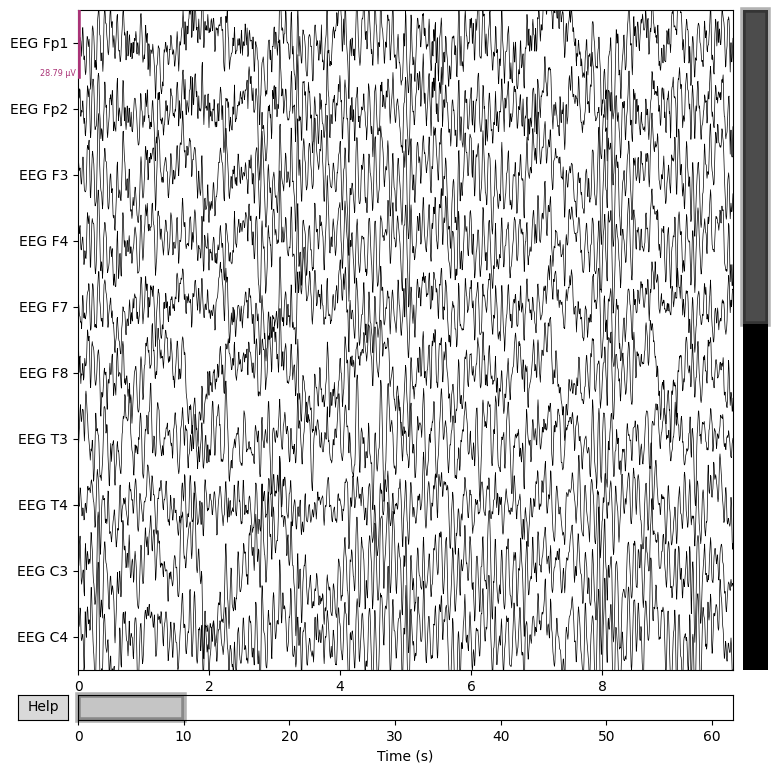

In [10]:
# Plotting the raw EEG

raw.plot(
    duration=10,
    n_channels=min(10, len(raw.ch_names)),
    scalings="auto"
)
plt.show()

In [11]:
# Gathering the numerical data

data, times = raw.get_data(return_times=True)
print("Data shape:", data.shape)
print("Time shape:", times.shape)

Data shape: (21, 31000)
Time shape: (31000,)


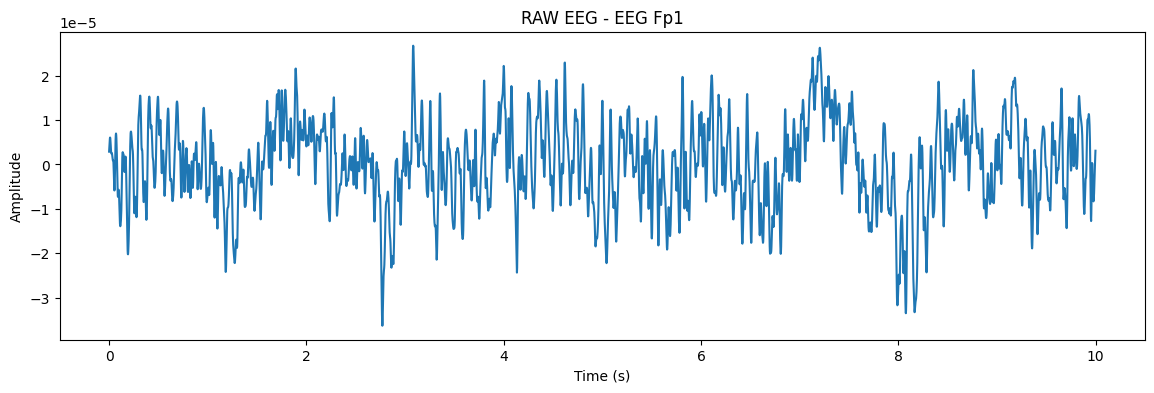

In [12]:
# Isolating first channel

channel_idx = 0
eeg_signal = data[channel_idx]

plt.figure(figsize=(14, 4))
plt.plot(times[:5000], eeg_signal[:5000])

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"RAW EEG - {raw.ch_names[channel_idx]}")

plt.show()

In [13]:
print(raw)
print("Sampling frequency:", raw.info["sfreq"])
print("Number of channels:", len(raw.ch_names))
print("Duration:", raw.times[-1])
print(raw.ch_names)
print(data.shape)

<RawEDF | Subject29_2.edf, 21 x 31000 (62.0 s), ~5.0 MiB, data loaded>
Sampling frequency: 500.0
Number of channels: 21
Duration: 61.998
['EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG T3', 'EEG T4', 'EEG C3', 'EEG C4', 'EEG T5', 'EEG T6', 'EEG P3', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG Fz', 'EEG Cz', 'EEG Pz', 'EEG A2-A1', 'ECG ECG']
(21, 31000)


# PHASE 1 - Inspecting metadata & annotations

In [14]:
print("\n===== BASIC INFORMATION =====")
print(raw)

print("\n===== CHANNEL TYPES =====")
print(raw.get_channel_types())

print("\n===== EEG CHANNELS =====")
eeg_channels = mne.pick_types(
    raw.info,
    eeg=True,
    exclude=[]
)

print("Number of EEG channels:", len(eeg_channels))
print([raw.ch_names[i] for i in eeg_channels])

print("\n===== ECG CHANNEL =====")
ecg_channels = mne.pick_types(
    raw.info,
    ecg=True
)

print([raw.ch_names[i] for i in ecg_channels])

print("\n===== ANNOTATIONS =====")
print(raw.annotations)


===== BASIC INFORMATION =====
<RawEDF | Subject29_2.edf, 21 x 31000 (62.0 s), ~5.0 MiB, data loaded>

===== CHANNEL TYPES =====
['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg']

===== EEG CHANNELS =====
Number of EEG channels: 21
['EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG T3', 'EEG T4', 'EEG C3', 'EEG C4', 'EEG T5', 'EEG T6', 'EEG P3', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG Fz', 'EEG Cz', 'EEG Pz', 'EEG A2-A1', 'ECG ECG']

===== ECG CHANNEL =====
[]

===== ANNOTATIONS =====
<Annotations | 0 segments>


In [15]:
print("Number of annotations:", len(raw.annotations))

if len(raw.annotations) > 0:
  print(raw.annotations.description)

Number of annotations: 0


In [16]:
# Plot the EEG(explicitly exclude ECG)

eeg_raw = raw.copy().pick("eeg")
print(eeg_raw)

<RawEDF | Subject29_2.edf, 21 x 31000 (62.0 s), ~5.0 MiB, data loaded>


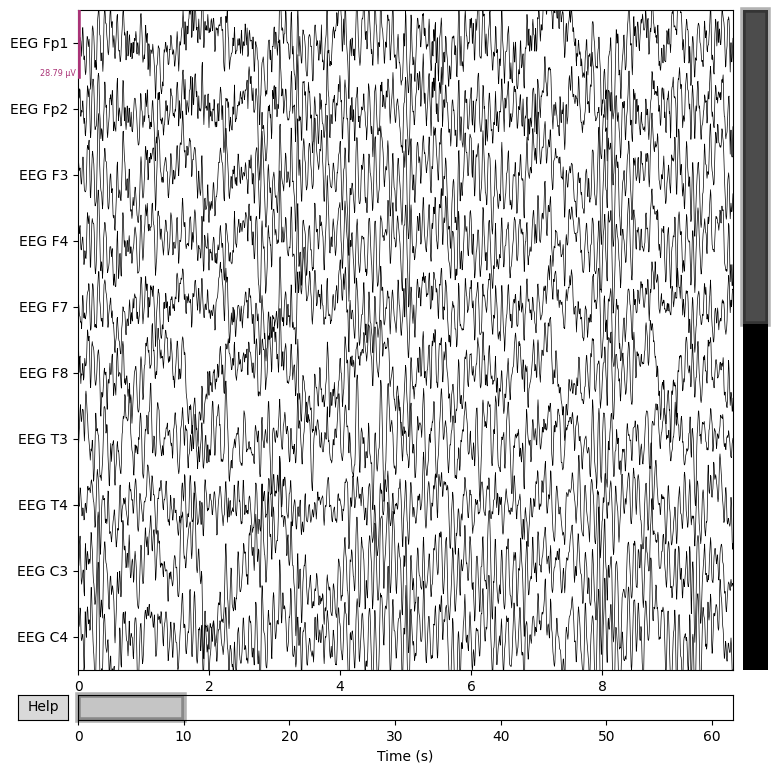

In [17]:
eeg_raw.plot(
    duration=10,
    n_channels=min(10, len(eeg_raw.ch_names)),
    scalings="auto",
    title="Raw EEG Signals"
)

plt.show()

In [18]:
print(eeg_raw.ch_names)

['EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG T3', 'EEG T4', 'EEG C3', 'EEG C4', 'EEG T5', 'EEG T6', 'EEG P3', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG Fz', 'EEG Cz', 'EEG Pz', 'EEG A2-A1', 'ECG ECG']


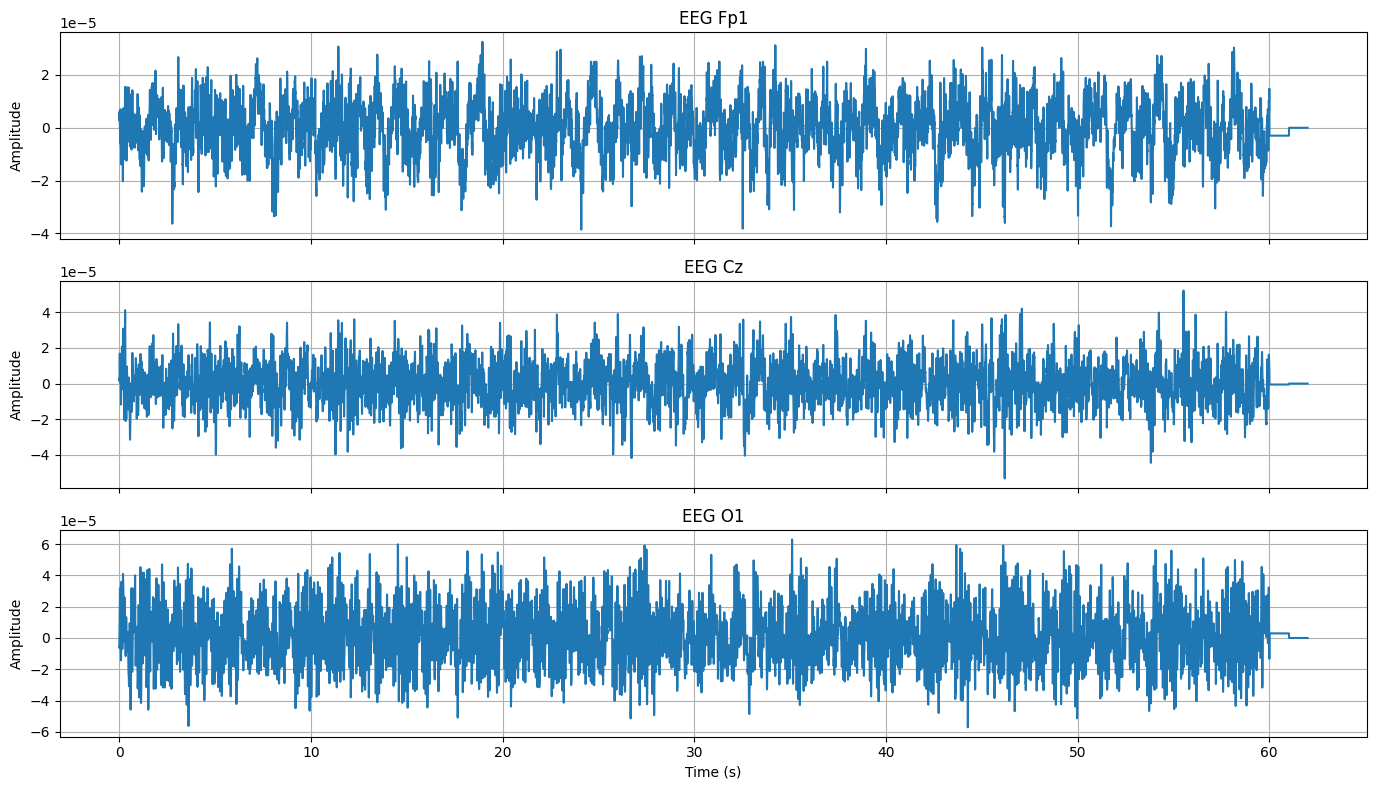

In [19]:
# Inspecting physiologically interesting regions: [Frontal(Fp1), Central(Cz) & Occipital(01)]
# Observing EEG morphology difference across scalp locations

channels_to_plot = [0, 17, 14]

fig, axes = plt.subplots(
    3, 1,
    figsize=(14, 8),
    sharex=True
)

for ax, idx in zip(axes, channels_to_plot):

    signal_data = eeg_raw.get_data(
        picks=[idx]
    )[0]

    ax.plot(
        eeg_raw.times,
        signal_data
    )

    ax.set_ylabel("Amplitude")
    ax.set_title(eeg_raw.ch_names[idx])
    ax.grid(True)

axes[-1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

# PHASE 2 - Signal Processing

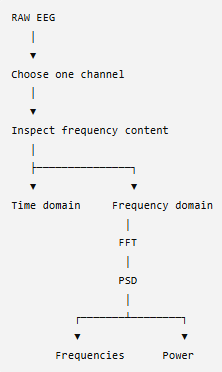

In [20]:
# What frequency components are actually present in this raw EEG, and how can we isolate the physiologically useful range?

from scipy.io import savemat

# Select Fp1
channel_name = "EEG Fp1"

eeg_fp1 = eeg_raw.get_data(
    picks=[channel_name]
)[0]

time = eeg_raw.times
fs = eeg_raw.info["sfreq"]

# Save MATLAB-compatible file
savemat(
    "/content/drive/MyDrive/eeg-during-mental-arithmetic-tasks-1.0.0/EEG_Fp1.mat",
    {
        "eeg": eeg_fp1,
        "time": time,
        "fs": fs
    }
)

print("Saved successfully!")
print("Samples:", len(eeg_fp1))
print("Sampling frequency:", fs)
print("Duration:", time[-1], "seconds")

Saved successfully!
Samples: 31000
Sampling frequency: 500.0
Duration: 61.998 seconds


# Inspecting actual labels/annotations in EEGMAT

In [21]:
print(eeg_raw.annotations)

<Annotations | 0 segments>


In [22]:
print(eeg_raw.annotations.description)

[]


### **Classification Problem identified** = *Can a model distinguish resting EEG from EEG recorded during mental arithmetic?*

In [23]:
# Locating all 36 subject files

import glob
import os

edf_files = sorted(glob.glob(
    "/content/drive/MyDrive/eeg-during-mental-arithmetic-tasks-1.0.0/*.edf"
))

print("Total EDF files:", len(edf_files))

print("\nFirst 10:")
for f in edf_files[:]:
    print(os.path.basename(f))

Total EDF files: 72

First 10:
Subject00_1.edf
Subject00_2.edf
Subject01_1.edf
Subject01_2.edf
Subject02_1.edf
Subject02_2.edf
Subject03_1.edf
Subject03_2.edf
Subject04_1.edf
Subject04_2.edf
Subject05_1.edf
Subject05_2.edf
Subject06_1.edf
Subject06_2.edf
Subject07_1.edf
Subject07_2.edf
Subject08_1.edf
Subject08_2.edf
Subject09_1.edf
Subject09_2.edf
Subject10_1.edf
Subject10_2.edf
Subject11_1.edf
Subject11_2.edf
Subject12_1.edf
Subject12_2.edf
Subject13_1.edf
Subject13_2.edf
Subject14_1.edf
Subject14_2.edf
Subject15_1.edf
Subject15_2.edf
Subject16_1.edf
Subject16_2.edf
Subject17_1.edf
Subject17_2.edf
Subject18_1.edf
Subject18_2.edf
Subject19_1.edf
Subject19_2.edf
Subject20_1.edf
Subject20_2.edf
Subject21_1.edf
Subject21_2.edf
Subject22_1.edf
Subject22_2.edf
Subject23_1.edf
Subject23_2.edf
Subject24_1.edf
Subject24_2.edf
Subject25_1.edf
Subject25_2.edf
Subject26_1.edf
Subject26_2.edf
Subject27_1.edf
Subject27_2.edf
Subject28_1.edf
Subject28_2.edf
Subject29_1.edf
Subject29_2.edf
Subject30

In [24]:
# Create the recording-level metadata

import glob
import os
import pandas as pd

edf_files = sorted(glob.glob(
    "/content/drive/MyDrive/eeg-during-mental-arithmetic-tasks-1.0.0/*.edf"
))

records = []

for file in edf_files:
    filename = os.path.basename(file)

    # Example: Subject00_2.edf
    subject = filename.split("_")[0]
    condition = filename.split("_")[1].replace(".edf", "")

    label = 0 if condition == "1" else 1
    condition_name = "rest" if label == 0 else "mental_arithmetic"

    records.append({
        "subject": subject,
        "file": file,
        "condition": condition_name,
        "label": label
    })

metadata = pd.DataFrame(records)

print(metadata.head())
print("\nTotal recordings:", len(metadata))
print("\nLabels:")
print(metadata["condition"].value_counts())
print("\nSubjects:", metadata["subject"].nunique())

     subject                                               file  \
0  Subject00  /content/drive/MyDrive/eeg-during-mental-arith...   
1  Subject00  /content/drive/MyDrive/eeg-during-mental-arith...   
2  Subject01  /content/drive/MyDrive/eeg-during-mental-arith...   
3  Subject01  /content/drive/MyDrive/eeg-during-mental-arith...   
4  Subject02  /content/drive/MyDrive/eeg-during-mental-arith...   

           condition  label  
0               rest      0  
1  mental_arithmetic      1  
2               rest      0  
3  mental_arithmetic      1  
4               rest      0  

Total recordings: 72

Labels:
condition
rest                 36
mental_arithmetic    36
Name: count, dtype: int64

Subjects: 36


In [25]:
# Inspecting one pair

import mne

rest_file = metadata[
    (metadata.subject == "Subject00") &
    (metadata.label == 0)
]["file"].iloc[0]

task_file = metadata[
    (metadata.subject == "Subject00") &
    (metadata.label == 1)
]["file"].iloc[0]

rest_raw = mne.io.read_raw_edf(
    rest_file,
    preload=True,
    verbose=False
)

task_raw = mne.io.read_raw_edf(
    task_file,
    preload=True,
    verbose=False
)

print("REST")
print(rest_raw)

print("\nMENTAL ARITHMETIC")
print(task_raw)

print("\nShapes:")
print("Rest:", rest_raw.get_data().shape)
print("Task:", task_raw.get_data().shape)

REST
<RawEDF | Subject00_1.edf, 21 x 91000 (182.0 s), ~14.6 MiB, data loaded>

MENTAL ARITHMETIC
<RawEDF | Subject00_2.edf, 21 x 31000 (62.0 s), ~5.0 MiB, data loaded>

Shapes:
Rest: (21, 91000)
Task: (21, 31000)


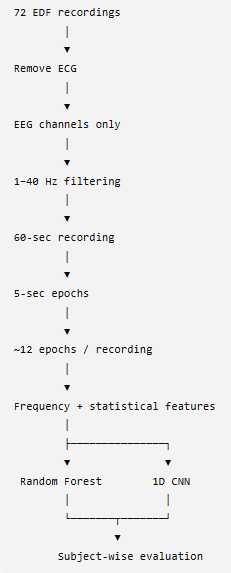

# **Why 1-40 Hz ?**


The dataset itself states that the recordings underwent preprocessing including a 30 Hz high-pass filter and 50 Hz power-line notch filtering, plus ICA artifact removal.

For our own reproducible ML pipeline, we'll explicitly document our preprocessing choices rather than pretending we're reproducing the original preprocessing exactly.

And we'll not blindly claim that our filtering removes every artifact.



# Building the ML-ready EEG dataset

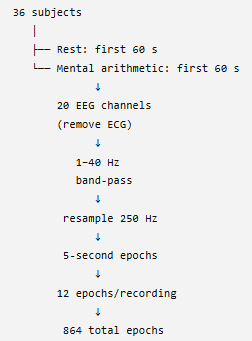

**WHY 864?**

36 subjects * 2 conditions * 12 epochs = 864 epochs.

Most importantly, the subject identity will be preserved so we can later do a subject-wise train/test split.

In [26]:
# Verifying all recordings as compatible

import mne
import numpy as np

print("Checking all recordings...\n")

sampling_rates = []
channel_counts = []
durations = []

for _, row in metadata.iterrows():

    raw = mne.io.read_raw_edf(
        row["file"],
        preload=False,
        verbose=False
    )

    sampling_rates.append(raw.info["sfreq"])
    channel_counts.append(len(raw.ch_names))
    durations.append(raw.times[-1])

print("Sampling rates:", sorted(set(sampling_rates)))
print("Channel counts:", sorted(set(channel_counts)))
print("Minimum duration:", min(durations))
print("Maximum duration:", max(durations))

Checking all recordings...

Sampling rates: [500.0]
Channel counts: [21]
Minimum duration: 61.998
Maximum duration: 187.998


In [27]:
# Actual preprocessing pipeline

import mne
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# --------------------------------------------------
# Configuration
# --------------------------------------------------

TARGET_DURATION = 60.0
LOW_CUT = 1.0
HIGH_CUT = 40.0
TARGET_SFREQ = 250
EPOCH_DURATION = 5.0

# 19 standard scalp EEG channels
EEG_CHANNELS = [
    "EEG Fp1", "EEG Fp2",
    "EEG F3", "EEG F4",
    "EEG F7", "EEG F8",
    "EEG T3", "EEG T4",
    "EEG C3", "EEG C4",
    "EEG T5", "EEG T6",
    "EEG P3", "EEG P4",
    "EEG O1", "EEG O2",
    "EEG Fz", "EEG Cz", "EEG Pz"
]

# --------------------------------------------------
# Storage
# --------------------------------------------------

all_epochs = []
all_labels = []
all_subjects = []
all_conditions = []

# --------------------------------------------------
# Process each recording
# --------------------------------------------------

for _, row in tqdm(
    metadata.iterrows(),
    total=len(metadata),
    desc="Processing EEG recordings"
):

    raw = mne.io.read_raw_edf(
        row["file"],
        preload=True,
        verbose=False
    )

    # Keep only scalp EEG channels
    raw.pick(EEG_CHANNELS)

    # Use exactly 60 seconds from each recording
    raw.crop(
        tmin=0,
        tmax=TARGET_DURATION,
        include_tmax=False
    )

    # Band-pass filter
    raw.filter(
        l_freq=LOW_CUT,
        h_freq=HIGH_CUT,
        verbose=False
    )

    # Downsample 500 Hz → 250 Hz
    raw.resample(
        TARGET_SFREQ,
        verbose=False
    )

    # Create fixed-length 5-second epochs
    epochs = mne.make_fixed_length_epochs(
        raw,
        duration=EPOCH_DURATION,
        preload=True,
        verbose=False
    )

    X = epochs.get_data().astype(np.float32)

    # Store
    all_epochs.append(X)

    all_labels.extend(
        [row["label"]] * len(X)
    )

    all_subjects.extend(
        [row["subject"]] * len(X)
    )

    all_conditions.extend(
        [row["condition"]] * len(X)
    )

# --------------------------------------------------
# Combine everything
# --------------------------------------------------

X = np.concatenate(all_epochs, axis=0)

y = np.array(all_labels)
subjects = np.array(all_subjects)
conditions = np.array(all_conditions)

print("\n========== DATASET ==========")

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass distribution:")
print(pd.Series(y).value_counts())

print("\nUnique subjects:", len(np.unique(subjects)))

print("\nConditions:")
print(pd.Series(conditions).value_counts())

Processing EEG recordings:   0%|          | 0/72 [00:00<?, ?it/s]


========== DATASET ==========
X shape: (864, 19, 1250)
y shape: (864,)

Class distribution:
0    432
1    432
Name: count, dtype: int64

Unique subjects: 36

Conditions:
rest                 432
mental_arithmetic    432
Name: count, dtype: int64


## Can simple frequency/statistical characteristics of EEG distinguish rest from mental arithmetic?

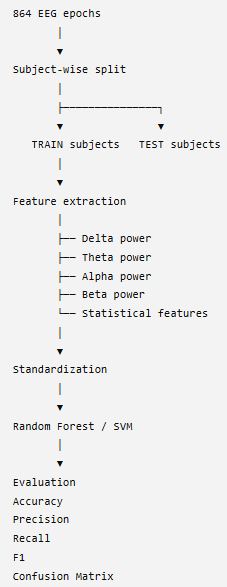

In [28]:
# Subject-wise train/test split

from sklearn.model_selection import GroupShuffleSplit
import numpy as np

# --------------------------------------------------
# Subject-wise train/test split
# --------------------------------------------------

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=subjects)
)

X_train = X[train_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

subjects_train = subjects[train_idx]
subjects_test = subjects[test_idx]

print("TRAIN")
print("Epochs:", X_train.shape[0])
print("Subjects:", len(np.unique(subjects_train)))
print("Class distribution:", np.bincount(y_train))

print("\nTEST")
print("Epochs:", X_test.shape[0])
print("Subjects:", len(np.unique(subjects_test)))
print("Class distribution:", np.bincount(y_test))

print("\nTrain subjects:")
print(sorted(np.unique(subjects_train)))

print("\nTest subjects:")
print(sorted(np.unique(subjects_test)))

# Verify NO subject appears in both sets
overlap = set(subjects_train) & set(subjects_test)

print("\nSubject overlap:", overlap)

TRAIN
Epochs: 672
Subjects: 28
Class distribution: [336 336]

TEST
Epochs: 192
Subjects: 8
Class distribution: [96 96]

Train subjects:
[np.str_('Subject00'), np.str_('Subject01'), np.str_('Subject02'), np.str_('Subject03'), np.str_('Subject04'), np.str_('Subject05'), np.str_('Subject06'), np.str_('Subject07'), np.str_('Subject08'), np.str_('Subject09'), np.str_('Subject10'), np.str_('Subject11'), np.str_('Subject14'), np.str_('Subject15'), np.str_('Subject17'), np.str_('Subject18'), np.str_('Subject19'), np.str_('Subject20'), np.str_('Subject22'), np.str_('Subject23'), np.str_('Subject24'), np.str_('Subject25'), np.str_('Subject27'), np.str_('Subject28'), np.str_('Subject29'), np.str_('Subject32'), np.str_('Subject33'), np.str_('Subject34')]

Test subjects:
[np.str_('Subject12'), np.str_('Subject13'), np.str_('Subject16'), np.str_('Subject21'), np.str_('Subject26'), np.str_('Subject30'), np.str_('Subject31'), np.str_('Subject35')]

Subject overlap: set()


In [29]:
# Extract EEG frequency-band features

import numpy as np
from scipy.signal import welch
from tqdm.auto import tqdm

# --------------------------------------------------
# EEG frequency bands
# --------------------------------------------------

BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 40)
}

SFREQ = 250


def extract_band_features(epoch, sfreq=250):
    """
    Extract absolute and relative frequency-band
    power from a single EEG epoch.

    epoch shape:
        (channels, samples)
    """

    features = []

    for channel in epoch:

        # Welch Power Spectral Density
        freqs, psd = welch(
            channel,
            fs=sfreq,
            nperseg=min(500, len(channel))
        )

        # Total power from 1–40 Hz
        total_mask = (freqs >= 1) & (freqs <= 40)

        total_power = np.trapezoid(
            psd[total_mask],
            freqs[total_mask]
        )

        channel_features = []

        for band_name, (low, high) in BANDS.items():

            band_mask = (
                (freqs >= low) &
                (freqs < high)
            )

            band_power = np.trapezoid(
                psd[band_mask],
                freqs[band_mask]
            )

            relative_power = (
                band_power / total_power
                if total_power > 0
                else 0
            )

            channel_features.extend([
                band_power,
                relative_power
            ])

        features.extend(channel_features)

    return np.array(features, dtype=np.float32)


# --------------------------------------------------
# Extract TRAIN features
# --------------------------------------------------

X_train_features = np.array([
    extract_band_features(epoch, SFREQ)
    for epoch in tqdm(
        X_train,
        desc="Extracting TRAIN features"
    )
])


# --------------------------------------------------
# Extract TEST features
# --------------------------------------------------

X_test_features = np.array([
    extract_band_features(epoch, SFREQ)
    for epoch in tqdm(
        X_test,
        desc="Extracting TEST features"
    )
])


print("\nFeature extraction complete!")

print("X_train_features shape:",
      X_train_features.shape)

print("X_test_features shape:",
      X_test_features.shape)

Extracting TRAIN features:   0%|          | 0/672 [00:00<?, ?it/s]

Extracting TEST features:   0%|          | 0/192 [00:00<?, ?it/s]


Feature extraction complete!
X_train_features shape: (672, 190)
X_test_features shape: (192, 190)


In [30]:
# Train the first baseline: SVM

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# --------------------------------------------------
# Standardization
# --------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)

# --------------------------------------------------
# SVM
# --------------------------------------------------

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

svm_model.fit(
    X_train_scaled,
    y_train
)

# --------------------------------------------------
# Prediction
# --------------------------------------------------

y_pred_svm = svm_model.predict(X_test_scaled)

# --------------------------------------------------
# Evaluation
# --------------------------------------------------

accuracy = accuracy_score(y_test, y_pred_svm)
precision = precision_score(y_test, y_pred_svm)
recall = recall_score(y_test, y_pred_svm)
f1 = f1_score(y_test, y_pred_svm)

print("========== SVM RESULTS ==========")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=[
            "Rest",
            "Mental Arithmetic"
        ]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

========== SVM RESULTS ==========
Accuracy : 0.5885
Precision: 0.5680
Recall   : 0.7396
F1 Score : 0.6425

Classification Report:
                   precision    recall  f1-score   support

             Rest       0.63      0.44      0.52        96
Mental Arithmetic       0.57      0.74      0.64        96

         accuracy                           0.59       192
        macro avg       0.60      0.59      0.58       192
     weighted avg       0.60      0.59      0.58       192


Confusion Matrix:
[[42 54]
 [25 71]]


The model has noticeable bias toward predicting mental arithmetic.

That's consistent with the precision/recall pattern: (MA recall = 73.96%; Precision=56.8%)

So it catches many arithmetic epochs but also incorrectly calls quite a few rest epochs "arithmetic."

In [31]:
# Random Forest baseline

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# --------------------------------------------------
# Random Forest
# --------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_features,
    y_train
)

# --------------------------------------------------
# Prediction
# --------------------------------------------------

y_pred_rf = rf_model.predict(X_test_features)

# --------------------------------------------------
# Evaluation
# --------------------------------------------------

accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

print("========== RANDOM FOREST RESULTS ==========")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "Rest",
            "Mental Arithmetic"
        ]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

========== RANDOM FOREST RESULTS ==========
Accuracy : 0.5521
Precision: 0.5439
Recall   : 0.6458
F1 Score : 0.5905

Classification Report:
                   precision    recall  f1-score   support

             Rest       0.56      0.46      0.51        96
Mental Arithmetic       0.54      0.65      0.59        96

         accuracy                           0.55       192
        macro avg       0.55      0.55      0.55       192
     weighted avg       0.55      0.55      0.55       192


Confusion Matrix:
[[44 52]
 [34 62]]


**What we've learned**

Both models show the same tendency:

They identify mental arithmetic better than rest.
Neither gives strong subject-independent separation.
SVM is our current best classical model. *italicized text*

**Next:**

Can a deep model learn temporal/spatial EEG patterns that aren't captured by our handcrafted spectral features?

# 1D CNN

In [32]:
# Prepare tensors

import torch
from torch.utils.data import TensorDataset, DataLoader

# --------------------------------------------------
# Convert EEG epochs to PyTorch tensors
# --------------------------------------------------

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

print("X_train:", X_train_tensor.shape)
print("X_test :", X_test_tensor.shape)
print("y_train:", y_train_tensor.shape)
print("y_test :", y_test_tensor.shape)

X_train: torch.Size([672, 19, 1250])
X_test : torch.Size([192, 19, 1250])
y_train: torch.Size([672])
y_test : torch.Size([192])


In [33]:
# Normalize EEG correctly

# --------------------------------------------------
# Channel-wise normalization using TRAIN only
# --------------------------------------------------

train_mean = X_train.mean(axis=(0, 2), keepdims=True)
train_std = X_train.std(axis=(0, 2), keepdims=True)

train_std[train_std == 0] = 1.0

X_train_norm = (
    X_train - train_mean
) / train_std

X_test_norm = (
    X_test - train_mean
) / train_std

print("Train mean shape:", train_mean.shape)
print("Train std shape :", train_std.shape)

print(
    "\nNormalized train mean:",
    X_train_norm.mean()
)

print(
    "Normalized train std:",
    X_train_norm.std()
)

Train mean shape: (1, 19, 1)
Train std shape : (1, 19, 1)

Normalized train mean: 4.222459e-09
Normalized train std: 1.0000002


In [34]:
# Create DataLoaders

# Convert normalized data to tensors

X_train_tensor = torch.tensor(
    X_train_norm,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_norm,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

# DataLoaders

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Testing batches :", len(test_loader))

Training batches: 21
Testing batches : 6


In [35]:
# Define CNN

# Ist MODEL
import torch.nn as nn

class EEG1DCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv1d(
                in_channels=19,
                out_channels=32,
                kernel_size=7,
                padding=3
            ),

            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=7,
                padding=3
            ),

            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(
                in_channels=64,
                out_channels=128,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(64, 2)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = EEG1DCNN().to(device)

print(model)
print("\nDevice:", device)

EEG1DCNN(
  (features): Sequential(
    (0): Conv1d(19, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=64, out_fe

## Creating a leakage-safe subject-wise train/validation split

In [36]:
from sklearn.model_selection import GroupShuffleSplit
import numpy as np

# X_train_norm, y_train, subjects_train
# already exist from the previous preprocessing/splitting steps.

gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=123
)

train_sub_idx, val_sub_idx = next(
    gss_val.split(
        X_train_norm,
        y_train,
        groups=subjects_train
    )
)

# Training portion
X_tr = X_train_norm[train_sub_idx]
y_tr = y_train[train_sub_idx]
subjects_tr = subjects_train[train_sub_idx]

# Validation portion
X_val = X_train_norm[val_sub_idx]
y_val = y_train[val_sub_idx]
subjects_val = subjects_train[val_sub_idx]

print("TRAINING SPLIT")
print("Epochs:", len(X_tr))
print("Subjects:", len(np.unique(subjects_tr)))
print("Class distribution:", np.bincount(y_tr))

print("\nVALIDATION SPLIT")
print("Epochs:", len(X_val))
print("Subjects:", len(np.unique(subjects_val)))
print("Class distribution:", np.bincount(y_val))

print("\nSubject overlap:",
      set(subjects_tr).intersection(set(subjects_val)))

TRAINING SPLIT
Epochs: 528
Subjects: 22
Class distribution: [264 264]

VALIDATION SPLIT
Epochs: 144
Subjects: 6
Class distribution: [72 72]

Subject overlap: set()


In [37]:
# ============================================================
# STEP 2 — PYTORCH DATALOADERS + CNN TRAINING
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import copy

# ------------------------------------------------------------
# 1. Convert NumPy arrays to PyTorch tensors
# ------------------------------------------------------------

X_tr_tensor = torch.tensor(X_tr, dtype=torch.float32)
y_tr_tensor = torch.tensor(y_tr, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

print("X_tr :", X_tr_tensor.shape)
print("y_tr :", y_tr_tensor.shape)

print("X_val:", X_val_tensor.shape)
print("y_val:", y_val_tensor.shape)


# ------------------------------------------------------------
# 2. Create datasets
# ------------------------------------------------------------

train_dataset = TensorDataset(
    X_tr_tensor,
    y_tr_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)


# ------------------------------------------------------------
# 3. Create DataLoaders
# ------------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("\nTraining batches:", len(train_loader))
print("Validation batches:", len(val_loader))


# ------------------------------------------------------------
# 4. Check device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nDevice:", device)


# ------------------------------------------------------------
# 5. Define CNN
# ------------------------------------------------------------

class EEG1DCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # Input: 19 channels × 1250 samples
            nn.Conv1d(
                in_channels=19,
                out_channels=32,
                kernel_size=7,
                padding=3
            ),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # 32 → 64
            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=7,
                padding=3
            ),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # 64 → 128
            nn.Conv1d(
                in_channels=64,
                out_channels=128,
                kernel_size=5,
                padding=2
            ),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            # Compress temporal dimension
            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(64, 2)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


# ------------------------------------------------------------
# 6. Initialize model
# ------------------------------------------------------------

model = EEG1DCNN().to(device)

print("\nModel:")
print(model)


# ------------------------------------------------------------
# 7. Loss + optimizer
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


# ------------------------------------------------------------
# 8. Training configuration
# ------------------------------------------------------------

NUM_EPOCHS = 40
PATIENCE = 7

best_val_loss = float("inf")
best_model_state = None
patience_counter = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}


# ------------------------------------------------------------
# 9. Training loop
# ------------------------------------------------------------

for epoch in range(NUM_EPOCHS):

    # ========================================================
    # TRAINING
    # ========================================================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_X, batch_y in train_loader:

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(batch_X)

        # Loss
        loss = criterion(outputs, batch_y)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * batch_X.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == batch_y
        ).sum().item()

        total += batch_y.size(0)

    train_loss = running_loss / total
    train_acc = correct / total


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for batch_X, batch_y in val_loader:

            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_X)

            loss = criterion(
                outputs,
                batch_y
            )

            val_running_loss += (
                loss.item() * batch_X.size(0)
            )

            predictions = outputs.argmax(dim=1)

            val_correct += (
                predictions == batch_y
            ).sum().item()

            val_total += batch_y.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total


    # ========================================================
    # SAVE HISTORY
    # ========================================================

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        patience_counter = 0

        best_marker = " ← BEST"

    else:

        patience_counter += 1

        best_marker = ""


    # ========================================================
    # PRINT RESULTS
    # ========================================================

    print(
        f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
        f"{best_marker}"
    )


    # ========================================================
    # STOP IF VALIDATION LOSS STOPS IMPROVING
    # ========================================================

    if patience_counter >= PATIENCE:

        print("\nEarly stopping triggered.")
        break


# ------------------------------------------------------------
# 10. Restore BEST model
# ------------------------------------------------------------

model.load_state_dict(best_model_state)

print("\nTraining complete.")
print(
    f"Best validation loss: {best_val_loss:.4f}"
)

X_tr : torch.Size([528, 19, 1250])
y_tr : torch.Size([528])
X_val: torch.Size([144, 19, 1250])
y_val: torch.Size([144])

Training batches: 17
Validation batches: 5

Device: cuda

Model:
EEG1DCNN(
  (features): Sequential(
    (0): Conv1d(19, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): F

This is exactly why we separated:

28 training subjects → training/validation
8 completely unseen subjects → final test

We haven't touched the final test set, so our experiment is still clean.

Our existing benchmark is:

* **SVM:** 58.85% epoch-level test accuracy
* **Random Forest:** 55.21%
* **CNN:** validation best = 62.5% — but this is NOT comparable to the final test yet

In [38]:
# Final CNN test evluation

# ============================================================
# STEP 3 — FINAL CNN EVALUATION ON UNTOUCHED TEST SET
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. Convert final test set to tensors
# ------------------------------------------------------------

X_test_tensor = torch.tensor(
    X_test_norm,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Test tensor:", X_test_tensor.shape)
print("Test labels:", y_test_tensor.shape)


# ------------------------------------------------------------
# 2. Evaluate BEST CNN
# ------------------------------------------------------------

model.eval()

all_predictions = []
all_probabilities = []
all_targets = []

with torch.no_grad():

    for batch_X, batch_y in test_loader:

        batch_X = batch_X.to(device)

        outputs = model(batch_X)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = outputs.argmax(
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

        all_targets.extend(
            batch_y.numpy()
        )


# ------------------------------------------------------------
# 3. Convert to NumPy
# ------------------------------------------------------------

y_pred_cnn = np.array(all_predictions)

y_prob_cnn = np.array(all_probabilities)

y_true_cnn = np.array(all_targets)


# ------------------------------------------------------------
# 4. Calculate metrics
# ------------------------------------------------------------

cnn_accuracy = accuracy_score(
    y_true_cnn,
    y_pred_cnn
)

cnn_precision = precision_score(
    y_true_cnn,
    y_pred_cnn,
    zero_division=0
)

cnn_recall = recall_score(
    y_true_cnn,
    y_pred_cnn,
    zero_division=0
)

cnn_f1 = f1_score(
    y_true_cnn,
    y_pred_cnn,
    zero_division=0
)


# ------------------------------------------------------------
# 5. Print results
# ------------------------------------------------------------

print("\n" + "="*55)
print("CNN — FINAL HELD-OUT TEST RESULTS")
print("="*55)

print(f"Accuracy : {cnn_accuracy:.4f}")
print(f"Precision: {cnn_precision:.4f}")
print(f"Recall   : {cnn_recall:.4f}")
print(f"F1 Score : {cnn_f1:.4f}")


# ------------------------------------------------------------
# 6. Classification report
# ------------------------------------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_true_cnn,
        y_pred_cnn,
        target_names=[
            "Rest",
            "Mental Arithmetic"
        ],
        digits=4,
        zero_division=0
    )
)


# ------------------------------------------------------------
# 7. Confusion matrix
# ------------------------------------------------------------

cm_cnn = confusion_matrix(
    y_true_cnn,
    y_pred_cnn
)

print("Confusion Matrix:")
print(cm_cnn)

Test tensor: torch.Size([192, 19, 1250])
Test labels: torch.Size([192])

CNN — FINAL HELD-OUT TEST RESULTS
Accuracy : 0.6302
Precision: 0.5912
Recall   : 0.8438
F1 Score : 0.6953

Classification Report:

                   precision    recall  f1-score   support

             Rest     0.7273    0.4167    0.5298        96
Mental Arithmetic     0.5912    0.8438    0.6953        96

         accuracy                         0.6302       192
        macro avg     0.6593    0.6302    0.6125       192
     weighted avg     0.6593    0.6302    0.6125       192

Confusion Matrix:
[[40 56]
 [15 81]]


In [39]:
# ============================================================
# STEP 4 — RECORDING-LEVEL CNN EVALUATION
# ============================================================

import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# 1. Get test metadata
# ------------------------------------------------------------

# These must correspond to the original test_idx used earlier.
subjects_test_final = subjects[test_idx]
conditions_test_final = conditions[test_idx]

print("Test epochs:", len(y_true_cnn))
print("Test subjects:", len(np.unique(subjects_test_final)))
print("Test recordings:",
      len(set(zip(
          subjects_test_final,
          conditions_test_final
      ))))


# ------------------------------------------------------------
# 2. Build recording-level dataframe
# ------------------------------------------------------------

recording_results = pd.DataFrame({
    "subject": subjects_test_final,
    "condition": conditions_test_final,
    "true_label": y_true_cnn,
    "predicted_label": y_pred_cnn,
    "prob_rest": y_prob_cnn[:, 0],
    "prob_mental": y_prob_cnn[:, 1]
})

# ------------------------------------------------------------
# 3. Aggregate 12 epochs → 1 recording
# ------------------------------------------------------------

recording_level = (
    recording_results
    .groupby(
        ["subject", "condition"],
        as_index=False
    )
    .agg(
        true_label=("true_label", "first"),
        mean_prob_rest=("prob_rest", "mean"),
        mean_prob_mental=("prob_mental", "mean"),
        epoch_count=("true_label", "count")
    )
)

# Prediction based on mean probability
recording_level["predicted_label"] = (
    recording_level["mean_prob_mental"] >= 0.5
).astype(int)


# ------------------------------------------------------------
# 4. Verify recordings
# ------------------------------------------------------------

print("\nRecording-level results:")
print(recording_level)

print(
    "\nEpochs per recording:"
)
print(
    recording_level["epoch_count"].value_counts()
)


# ------------------------------------------------------------
# 5. Calculate recording-level metrics
# ------------------------------------------------------------

y_true_recording = recording_level["true_label"].values
y_pred_recording = recording_level["predicted_label"].values

recording_accuracy = accuracy_score(
    y_true_recording,
    y_pred_recording
)

recording_precision = precision_score(
    y_true_recording,
    y_pred_recording,
    zero_division=0
)

recording_recall = recall_score(
    y_true_recording,
    y_pred_recording,
    zero_division=0
)

recording_f1 = f1_score(
    y_true_recording,
    y_pred_recording,
    zero_division=0
)


# ------------------------------------------------------------
# 6. Print final recording-level metrics
# ------------------------------------------------------------

print("\n" + "="*60)
print("CNN — RECORDING-LEVEL FINAL TEST RESULTS")
print("="*60)

print(
    f"Accuracy : {recording_accuracy:.4f}"
)

print(
    f"Precision: {recording_precision:.4f}"
)

print(
    f"Recall   : {recording_recall:.4f}"
)

print(
    f"F1 Score : {recording_f1:.4f}"
)


# ------------------------------------------------------------
# 7. Classification report
# ------------------------------------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_true_recording,
        y_pred_recording,
        target_names=[
            "Rest",
            "Mental Arithmetic"
        ],
        digits=4,
        zero_division=0
    )
)


# ------------------------------------------------------------
# 8. Confusion matrix
# ------------------------------------------------------------

cm_recording = confusion_matrix(
    y_true_recording,
    y_pred_recording
)

print("\nConfusion Matrix:")
print(cm_recording)

Test epochs: 192
Test subjects: 8
Test recordings: 16

Recording-level results:
      subject          condition  true_label  mean_prob_rest  \
0   Subject12  mental_arithmetic           1        0.680914   
1   Subject12               rest           0        0.513543   
2   Subject13  mental_arithmetic           1        0.336726   
3   Subject13               rest           0        0.373228   
4   Subject16  mental_arithmetic           1        0.439265   
5   Subject16               rest           0        0.481694   
6   Subject21  mental_arithmetic           1        0.411507   
7   Subject21               rest           0        0.504465   
8   Subject26  mental_arithmetic           1        0.414817   
9   Subject26               rest           0        0.548668   
10  Subject30  mental_arithmetic           1        0.439334   
11  Subject30               rest           0        0.593935   
12  Subject31  mental_arithmetic           1        0.449269   
13  Subject31           

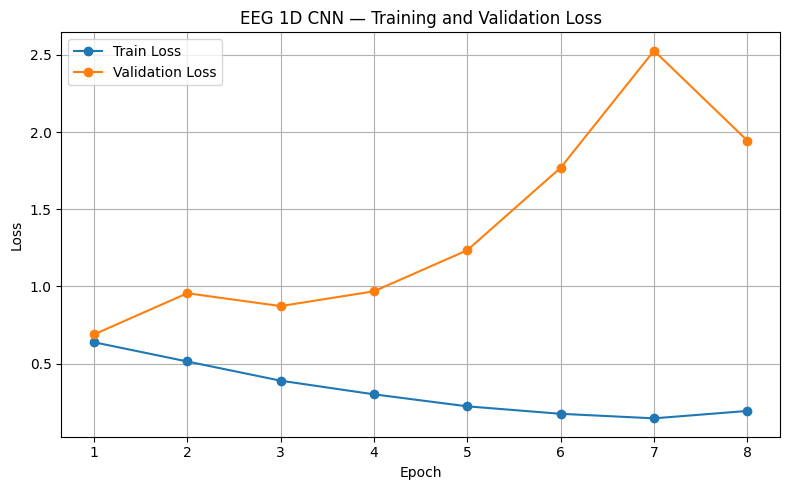

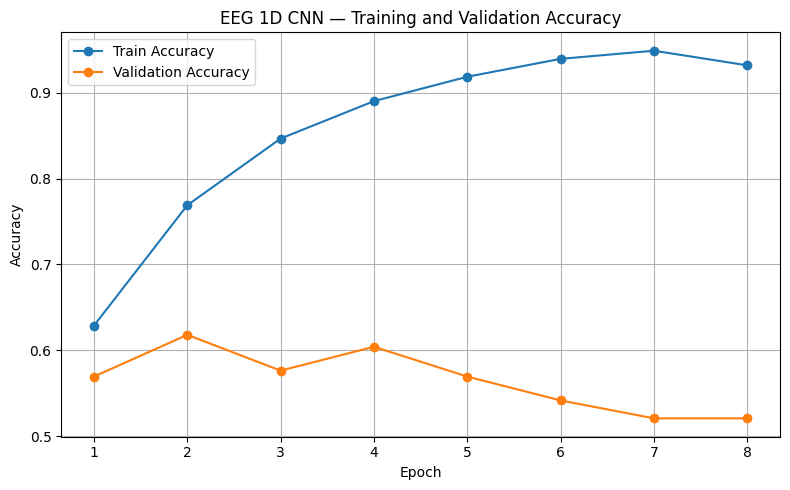

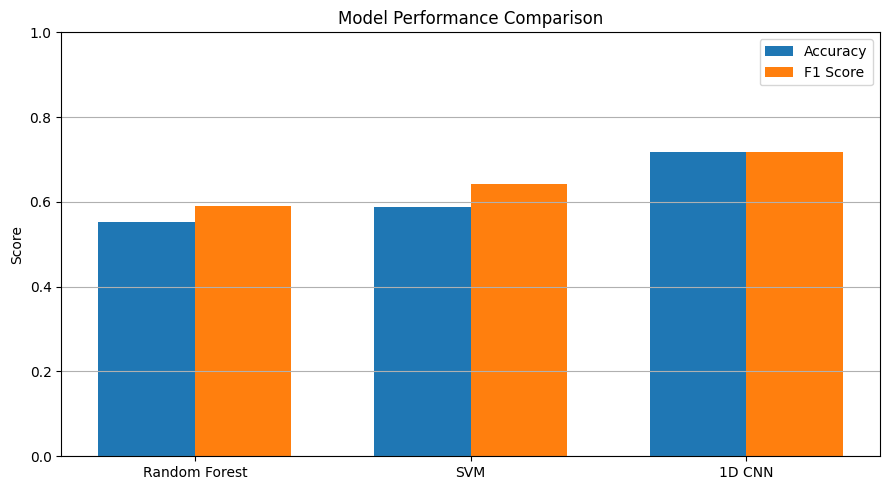

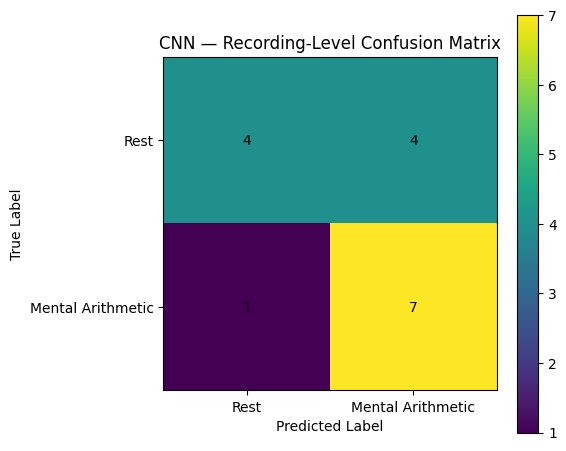

In [41]:
# ============================================================
# FINAL FIGURES — NeuroSignal-EEG
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. Training / Validation curves
# ------------------------------------------------------------

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EEG 1D CNN — Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(epochs, history["val_acc"], marker="o", label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EEG 1D CNN — Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Model comparison
# ------------------------------------------------------------

models = [
    "Random Forest",
    "SVM",
    "1D CNN"
]

accuracies = [
    0.5521,
    0.5885,
    0.7188
]

f1_scores = [
    0.5905,
    0.6425,
    0.7188
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    accuracies,
    width,
    label="Accuracy"
)

plt.bar(
    x + width/2,
    f1_scores,
    width,
    label="F1 Score"
)

plt.xticks(x, models)
plt.ylim(0, 1)

plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Recording-level confusion matrix
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))

plt.imshow(cm_recording)

plt.title("CNN — Recording-Level Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    [0, 1],
    ["Rest", "Mental Arithmetic"]
)

plt.yticks(
    [0, 1],
    ["Rest", "Mental Arithmetic"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_recording[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [42]:
# ============================================================
# SAVE BEST CNN MODEL
# ============================================================

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "model_class": "EEG1DCNN",
        "input_channels": 19,
        "input_samples": 1250,
        "sampling_frequency": 250,
        "classes": {
            0: "Rest",
            1: "Mental Arithmetic"
        }
    },
    "NeuroSignal_EEG_CNN.pt"
)

print("Saved: NeuroSignal_EEG_CNN.pt")

Saved: NeuroSignal_EEG_CNN.pt


In [43]:
from google.colab import files

files.download("NeuroSignal_EEG_CNN.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
# ============================================================
# SAVE PREPROCESSING PARAMETERS
# ============================================================

import pickle

preprocessing_config = {
    "channels": EEG_CHANNELS,
    "original_sampling_rate": 500,
    "target_sampling_rate": 250,
    "bandpass": [1.0, 40.0],
    "epoch_duration_seconds": 5.0,
    "epoch_samples": 1250,
    "target_duration_seconds": 60.0,
    "train_mean": train_mean,
    "train_std": train_std
}

with open(
    "NeuroSignal_EEG_preprocessing.pkl",
    "wb"
) as f:
    pickle.dump(preprocessing_config, f)

print("Saved: NeuroSignal_EEG_preprocessing.pkl")

Saved: NeuroSignal_EEG_preprocessing.pkl


In [45]:
# ============================================================
# FINAL RESULTS SUMMARY
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SVM",
        "1D CNN"
    ],
    "Epoch Accuracy": [
        0.5521,
        0.5885,
        0.7188
    ],
    "Epoch F1": [
        0.5905,
        0.6425,
        0.7188
    ]
})

print(results.to_string(index=False))

print("\nCNN Recording-Level Performance")
print("--------------------------------")
print(f"Accuracy : {recording_accuracy:.4f}")
print(f"Precision: {recording_precision:.4f}")
print(f"Recall   : {recording_recall:.4f}")
print(f"F1 Score : {recording_f1:.4f}")

        Model  Epoch Accuracy  Epoch F1
Random Forest          0.5521    0.5905
          SVM          0.5885    0.6425
       1D CNN          0.7188    0.7188

CNN Recording-Level Performance
--------------------------------
Accuracy : 0.6875
Precision: 0.6364
Recall   : 0.8750
F1 Score : 0.7368
